# Lab 14 – Complex Computing Activity
## Face Emotion Recognition with Live Webcam Overlay

**Project Name:** Face Emotion Recognition with Live Webcam Overlay  
**Roll No.:** 23-AI-40  
**Dataset:** FER-2013 (7 emotion classes, ~35,000 grayscale 48×48 images)


In [ ]:
import os, sys, time, random, warnings
from collections import deque
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import cv2
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks, optimizers, applications
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, f1_score
warnings.filterwarnings('ignore')
print("TensorFlow:", tf.__version__)
print("OpenCV:", cv2.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow: 2.20.0
OpenCV: 4.13.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


Load Dataset from Kaggle

In [ ]:
import kagglehub
path = kagglehub.dataset_download("msambare/fer2013")
print("Path to dataset files:", path)
DATA_ROOT = Path(path)
print("\nDirectory structure:")
for p in sorted(DATA_ROOT.rglob("*"))[:30]:
    print(" ", p.relative_to(DATA_ROOT))

Using Colab cache for faster access to the 'fer2013' dataset.
Path to dataset files: /kaggle/input/fer2013

Directory structure:
  test
  test/angry
  test/angry/PrivateTest_10131363.jpg
  test/angry/PrivateTest_10304478.jpg
  test/angry/PrivateTest_1054527.jpg
  test/angry/PrivateTest_10590091.jpg
  test/angry/PrivateTest_1109992.jpg
  test/angry/PrivateTest_11296953.jpg
  test/angry/PrivateTest_12000629.jpg
  test/angry/PrivateTest_12008383.jpg
  test/angry/PrivateTest_12191716.jpg
  test/angry/PrivateTest_1221822.jpg
  test/angry/PrivateTest_12403575.jpg
  test/angry/PrivateTest_12766285.jpg
  test/angry/PrivateTest_12846357.jpg
  test/angry/PrivateTest_1290484.jpg
  test/angry/PrivateTest_12912780.jpg
  test/angry/PrivateTest_13164119.jpg
  test/angry/PrivateTest_13278552.jpg
  test/angry/PrivateTest_13463625.jpg
  test/angry/PrivateTest_13541561.jpg
  test/angry/PrivateTest_13664224.jpg
  test/angry/PrivateTest_14325168.jpg
  test/angry/PrivateTest_14426977.jpg
  test/angry/Privat

In [ ]:
TRAIN_DIR = DATA_ROOT / 'train'
TEST_DIR  = DATA_ROOT / 'test'
EMOTIONS  = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()])
NUM_CLASSES = len(EMOTIONS)
print("Emotion classes:", EMOTIONS)
print("Num classes:", NUM_CLASSES)
train_counts = {e: len(list((TRAIN_DIR/e).glob('*.jpg'))) for e in EMOTIONS}
test_counts  = {e: len(list((TEST_DIR/e).glob('*.jpg')))  for e in EMOTIONS}
print("\nTrain samples per class:", train_counts)
print("Test samples per class: ", test_counts)

Emotion classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Num classes: 7

Train samples per class: {'angry': 3995, 'disgust': 436, 'fear': 4097, 'happy': 7215, 'neutral': 4965, 'sad': 4830, 'surprise': 3171}
Test samples per class:  {'angry': 958, 'disgust': 111, 'fear': 1024, 'happy': 1774, 'neutral': 1233, 'sad': 1247, 'surprise': 831}


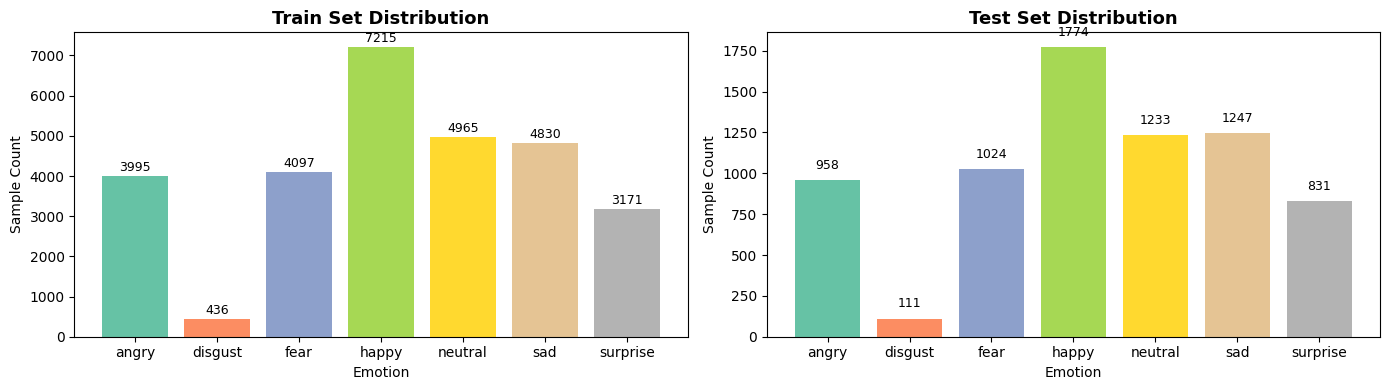

Total train samples: 28709
Total test  samples: 7178


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, counts, title in zip(axes,
                              [train_counts, test_counts],
                              ['Train Set Distribution', 'Test Set Distribution']):
    bars = ax.bar(counts.keys(), counts.values(),
                  color=plt.cm.Set2(np.linspace(0, 1, NUM_CLASSES)))
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel('Emotion')
    ax.set_ylabel('Sample Count')
    for bar, val in zip(bars, counts.values()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                str(val), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Total train samples:", sum(train_counts.values()))
print("Total test  samples:", sum(test_counts.values()))

Image Preprocessing

In [ ]:
IMG_SIZE_GRAY = 48
IMG_SIZE_COLOR = 96
BATCH_SIZE = 64
EPOCHS_SCRATCH = 50
EPOCHS_FINETUNE = 20
def preprocess_face_gray(img_bgr):
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (3, 3), 0)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    eq = clahe.apply(blurred)
    resized = cv2.resize(eq, (IMG_SIZE_GRAY, IMG_SIZE_GRAY))
    norm = resized.astype('float32') / 255.0
    return norm[..., np.newaxis]

def preprocess_face_color(img_bgr):
    rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    resized = cv2.resize(rgb, (IMG_SIZE_COLOR, IMG_SIZE_COLOR))
    return applications.mobilenet_v2.preprocess_input(resized.astype('float32'))
print("Preprocessing functions defined.")

Preprocessing functions defined.


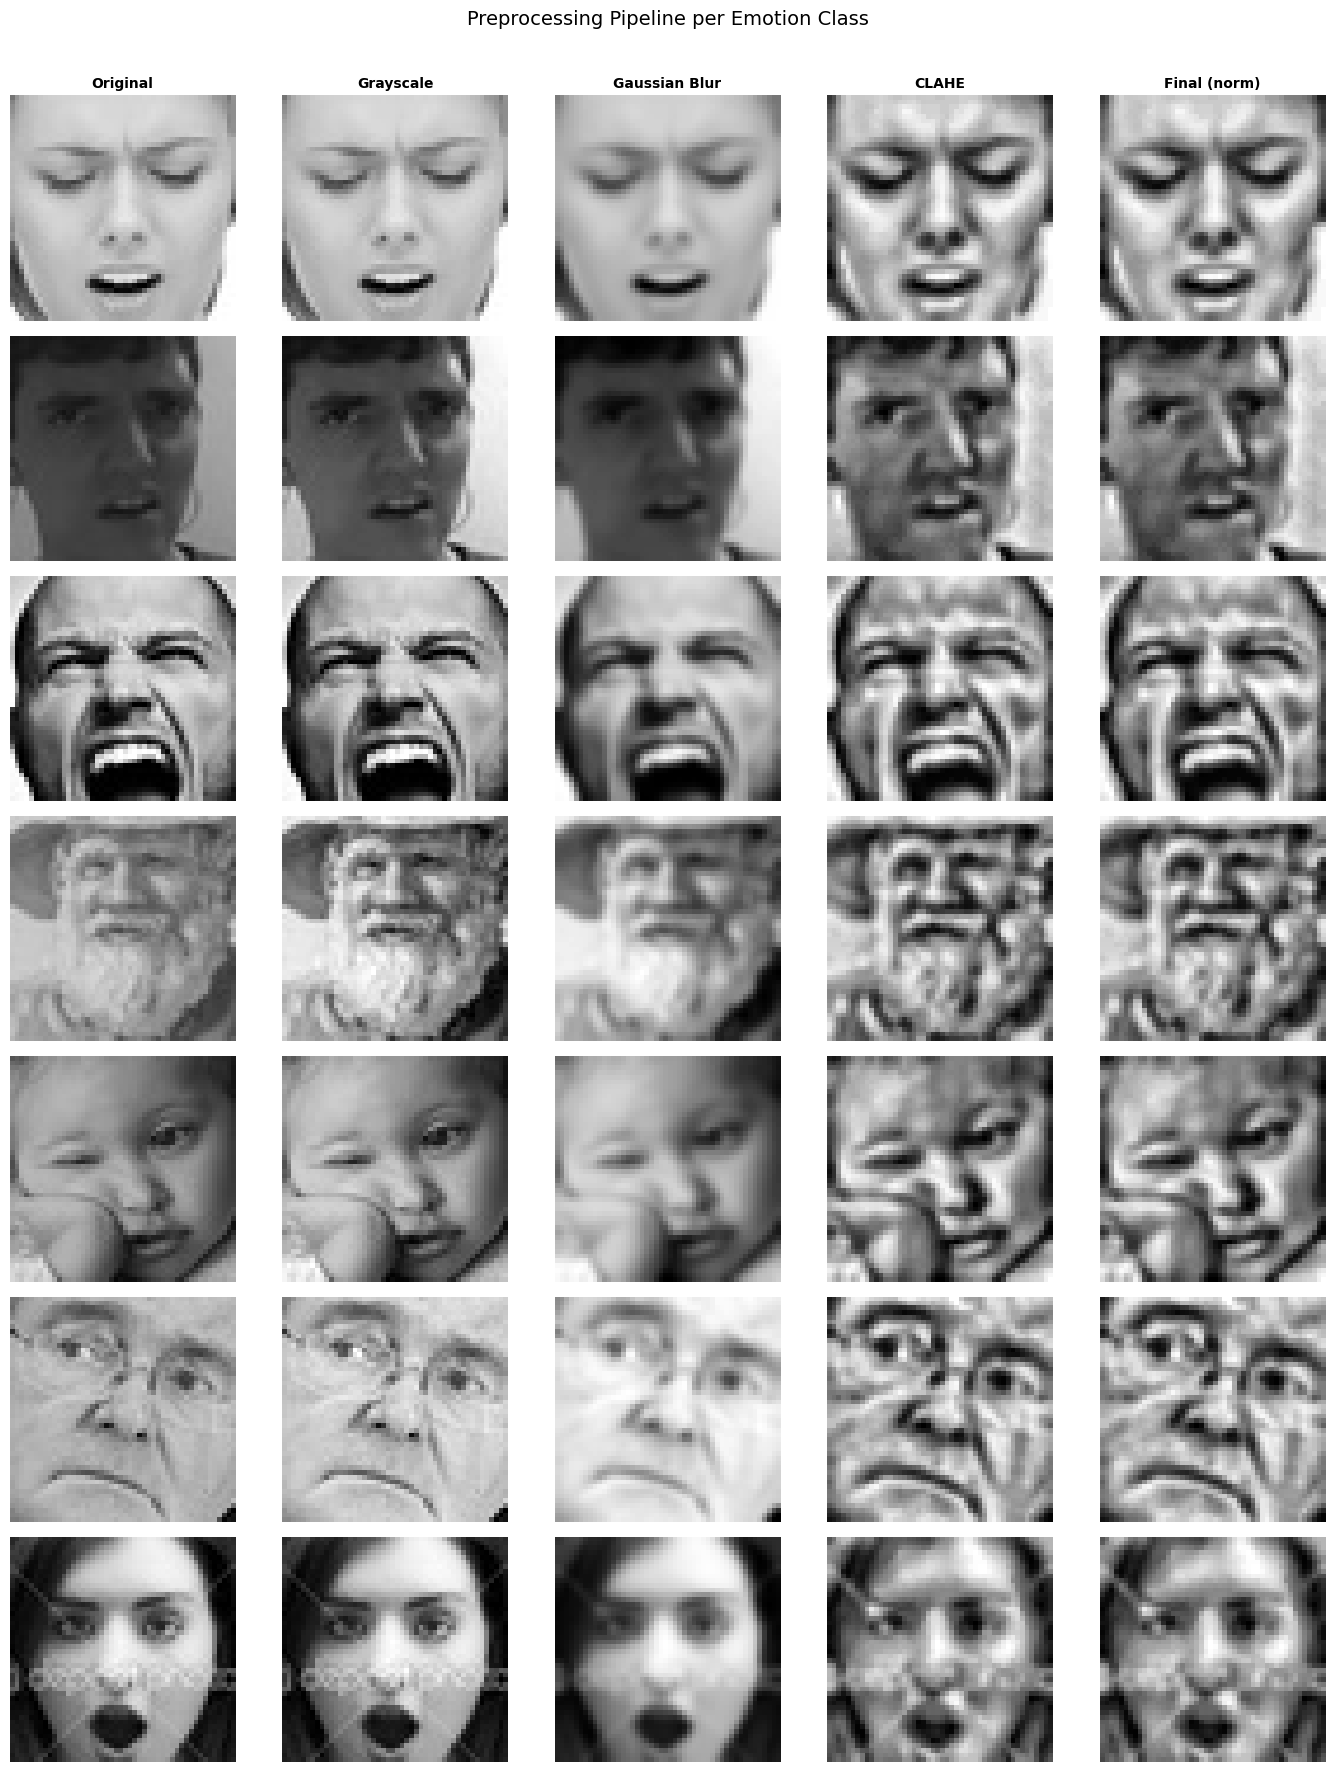

In [ ]:
fig, axes = plt.subplots(len(EMOTIONS), 5, figsize=(14, 2.5 * len(EMOTIONS)))
steps = ['Original', 'Grayscale', 'Gaussian Blur', 'CLAHE', 'Final (norm)']
for row, emotion in enumerate(EMOTIONS):
    img_path = list((TRAIN_DIR / emotion).glob('*.jpg'))[0]
    img_bgr = cv2.imread(str(img_path))
    gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (3, 3), 0)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    eq = clahe.apply(blurred)
    resized = cv2.resize(eq, (IMG_SIZE_GRAY, IMG_SIZE_GRAY))
    imgs = [cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB), gray, blurred, eq, resized]
    cmaps = [None, 'gray', 'gray', 'gray', 'gray']
    for col, (im, cmap, step) in enumerate(zip(imgs, cmaps, steps)):
        axes[row, col].imshow(im, cmap=cmap)
        axes[row, col].axis('off')
        if row == 0:
            axes[row, col].set_title(step, fontsize=10, fontweight='bold')
        if col == 0:
            axes[row, col].set_ylabel(emotion, fontsize=9, rotation=90, labelpad=10)
plt.suptitle('Preprocessing Pipeline per Emotion Class', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('preprocessing_pipeline.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
def load_and_preprocess_gray(file_path, label):#For CNN and VGG
    raw = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(raw, channels=1)
    img = tf.image.resize(img, [IMG_SIZE_GRAY, IMG_SIZE_GRAY])
    img = tf.cast(img, tf.float32) / 255.0
    return img, label

def load_and_preprocess_color(file_path, label):#For mobilenet
    raw = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(raw, channels=3)
    img = tf.image.resize(img, [IMG_SIZE_COLOR, IMG_SIZE_COLOR])
    img = tf.keras.applications.mobilenet_v2.preprocess_input(tf.cast(img, tf.float32))
    return img, label

def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, max_delta=0.1)
    img = tf.image.random_contrast(img, lower=0.8, upper=1.2)
    return img, label

def build_dataset(directory, preprocess_fn, augment_data=False, shuffle=True):
    file_paths, labels = [], []
    for idx, emotion in enumerate(EMOTIONS):
        imgs = list((directory / emotion).glob('*.jpg'))
        file_paths.extend([str(p) for p in imgs])
        labels.extend([idx] * len(imgs))
    ds = tf.data.Dataset.from_tensor_slices(
            (file_paths, tf.one_hot(labels, NUM_CLASSES)))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(file_paths), seed=42)
    ds = ds.map(preprocess_fn, num_parallel_calls=tf.data.AUTOTUNE)
    if augment_data:
        ds = ds.map(augment, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds
train_ds_gray = build_dataset(TRAIN_DIR,load_and_preprocess_gray, augment_data=True)
val_ds_gray = build_dataset(TEST_DIR,load_and_preprocess_gray, augment_data=False, shuffle=False)
train_ds_color = build_dataset(TRAIN_DIR,load_and_preprocess_color, augment_data=True)
val_ds_color = build_dataset(TEST_DIR,load_and_preprocess_color, augment_data=False, shuffle=False)

print("Gray train batches :", len(train_ds_gray))
print("Gray val batches :", len(val_ds_gray))
print("Color train batches:", len(train_ds_color))

Gray train batches : 449
Gray val   batches : 113
Color train batches: 449


In [ ]:
def build_scratch_cnn(input_shape=(48, 48, 1), num_classes=7):#CNN
    inp = layers.Input(shape=input_shape, name='input')
    #First Block with 32 filters
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)
    #Second Block with 64 filters
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)
    #Third Block with 128
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(128, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)
    model = models.Model(inp, out, name='scratch_cnn')
    return model
scratch_model = build_scratch_cnn()
scratch_model.summary()
print(f"\nTrainable params: {scratch_model.count_params():,}")

Model: "scratch_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 6, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 323,047 (1.23 MB)

 Trainable params: 322,151 (1.23 MB)

 Non-trainable params: 896 (3.50 KB)


Trainable params: 323,047


In [ ]:
def build_pretrained_model(input_shape=(96, 96, 3), num_classes=7, trainable=False):
    base = applications.MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights='imagenet'
    )

    if not trainable:
        base.trainable = False        # Freeze all backbone layers
    else:
        base.trainable = True
        # Unfreeze only the last 30 layers for fine-tuning
        for layer in base.layers[:-30]:
            layer.trainable = False

    inp = layers.Input(shape=input_shape, name='input_color')
    x   = base(inp, training=False)
    x   = layers.GlobalAveragePooling2D()(x)
    x   = layers.Dense(512, activation='relu')(x)
    x   = layers.Dropout(0.4)(x)
    x   = layers.Dense(256, activation='relu')(x)
    x   = layers.Dropout(0.3)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)

    name = 'mobilenetv2_frozen' if not trainable else 'mobilenetv2_finetuned'
    model = models.Model(inp, out, name=name)
    return model


pretrained_frozen_model = build_pretrained_model(trainable=False)
pretrained_frozen_model.summary()
print(f"\nTrainable params: {pretrained_frozen_model.count_params():,}")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "mobilenetv2_frozen"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_color (InputLayer)        │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │       655,872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,046,983 (11.62 MB)

 Trainable params: 788,999 (3.01 MB)

 Non-trainable params: 2,257,984 (8.61 MB)


Trainable params: 3,046,983


In [ ]:
# ── Architecture 3: VGG-Style Double Conv Block Variant ───────────────────

def vgg_double_conv_block(x, filters, dropout_rate=0.3, name=''):
    """
    VGG-style double conv block:
      Conv(3×3) → BN → ReLU → Conv(3×3) → BN → ReLU → MaxPool → Dropout
    This mirrors the VGG philosophy of stacking small receptive-field convolutions
    before pooling, giving a larger effective receptive field with fewer parameters.
    """
    x = layers.Conv2D(filters, 3, padding='same', name=f'{name}_conv1')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(filters, 3, padding='same', name=f'{name}_conv2')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(dropout_rate)(x)
    return x


def build_vgg_style_model(input_shape=(48, 48, 1), num_classes=7):
    """
    VGG-style model: 4 double-conv blocks → flatten → dense head.
    Variant: uses BatchNorm after each conv (unlike original VGG which did not).
    Input: (48, 48, 1) grayscale, normalised.
    """
    inp = layers.Input(shape=input_shape, name='input_vgg')

    x = vgg_double_conv_block(inp, 32,  dropout_rate=0.25, name='block1')
    x = vgg_double_conv_block(x,   64,  dropout_rate=0.25, name='block2')
    x = vgg_double_conv_block(x,   128, dropout_rate=0.30, name='block3')

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(512, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(num_classes, activation='softmax')(x)

    model = models.Model(inp, out, name='vgg_style')
    return model


vgg_model = build_vgg_style_model()
vgg_model.summary()
print(f"\nTrainable params: {vgg_model.count_params():,}")

Model: "vgg_style"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_vgg (InputLayer)          │ (None, 48, 48, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 48, 48, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 48, 48, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 48, 48, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 24, 24, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 24, 24, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 24, 24, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 24, 24, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 12, 12, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 12, 12, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 12, 12, 128)    │           512 │
│ (BatchNormalization)            │                        │             

 Total params: 487,399 (1.86 MB)

 Trainable params: 486,503 (1.86 MB)

 Non-trainable params: 896 (3.50 KB)


Trainable params: 487,399


## Section 6 — Training All Three Models

In [ ]:
# ── Shared training utilities ──────────────────────────────────────────────

def get_callbacks(model_name):
    """Return standard set of Keras callbacks."""
    return [
        callbacks.ModelCheckpoint(
            filepath=f'best_{model_name}.keras',
            monitor='val_accuracy', save_best_only=True, verbose=1),
        callbacks.EarlyStopping(
            monitor='val_accuracy', patience=8,
            restore_best_weights=True, verbose=1),
        callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=4,
            min_lr=1e-6, verbose=1),
    ]


def compile_and_train(model, train_ds, val_ds, epochs, lr=1e-3, model_name='model'):
    """Compile with Adam + categorical crossentropy, then train."""
    model.compile(
        optimizer=optimizers.Adam(learning_rate=lr),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    t0 = time.time()
    history = model.fit(
        train_ds, validation_data=val_ds,
        epochs=epochs,
        callbacks=get_callbacks(model_name),
        verbose=1
    )
    elapsed = time.time() - t0
    print(f"\n⏱  Training time: {elapsed/60:.1f} min")
    return history, elapsed


def plot_history(history, title):
    """Plot training / validation accuracy and loss curves."""
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, metric in zip(axes, ['accuracy', 'loss']):
        ax.plot(history.history[metric],       label='Train', linewidth=2)
        ax.plot(history.history[f'val_{metric}'], label='Val',   linewidth=2)
        ax.set_title(f'{title} — {metric.capitalize()}', fontsize=12)
        ax.set_xlabel('Epoch')
        ax.legend()
        ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f'{title.lower().replace(" ","_")}_history.png',
                dpi=150, bbox_inches='tight')
    plt.show()

print("Utilities defined.")

Utilities defined.


TRAINING MODEL 1: CNN from Scratch
Epoch 1/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step - accuracy: 0.2475 - loss: 1.8828
Epoch 1: val_accuracy improved from None to 0.30552, saving model to best_scratch_cnn.keras

Epoch 1: finished saving model to best_scratch_cnn.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 123s 245ms/step - accuracy: 0.3034 - loss: 1.7347 - val_accuracy: 0.3055 - val_loss: 1.7802 - learning_rate: 0.0010
Epoch 2/50
448/449 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.4458 - loss: 1.4395
Epoch 2: val_accuracy improved from 0.30552 to 0.49150, saving model to best_scratch_cnn.keras

Epoch 2: finished saving model to best_scratch_cnn.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 21s 48ms/step - accuracy: 0.4639 - loss: 1.3941 - val_accuracy: 0.4915 - val_loss: 1.3325 - learning_rate: 0.0010
Epoch 3/50
448/449 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.5119 - loss: 1.2865
Epoch 3: val_accuracy improved from 0.49150 to 0.53274, saving model to best_scratch_cnn.keras

Epoch 3: finishe

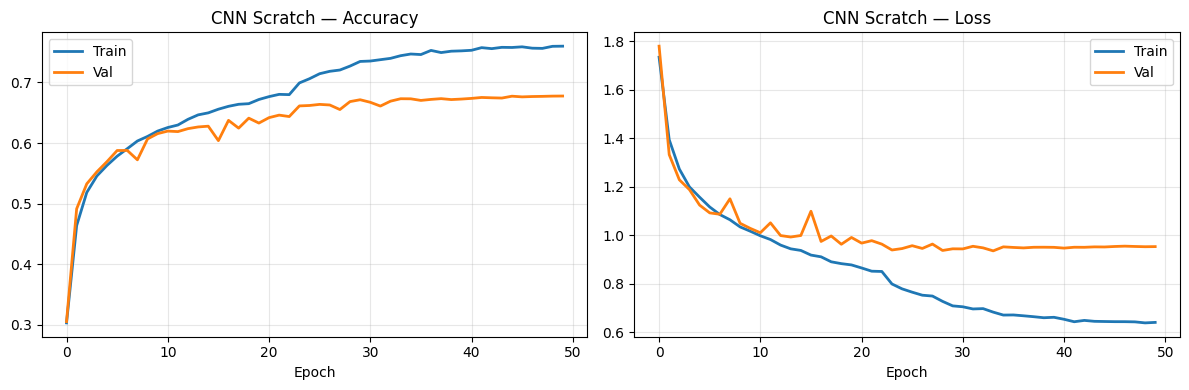

In [ ]:
# ── Train Model 1: CNN Scratch ─────────────────────────────────────────────
print("=" * 60)
print("TRAINING MODEL 1: CNN from Scratch")
print("=" * 60)

scratch_model = build_scratch_cnn()
history_scratch, time_scratch = compile_and_train(
    scratch_model, train_ds_gray, val_ds_gray,
    epochs=EPOCHS_SCRATCH, lr=1e-3, model_name='scratch_cnn'
)
plot_history(history_scratch, 'CNN Scratch')

TRAINING MODEL 2a: MobileNetV2 Frozen Backbone
Epoch 1/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 0.3232 - loss: 1.7517
Epoch 1: val_accuracy improved from None to 0.43578, saving model to best_mobilenet_frozen.keras

Epoch 1: finished saving model to best_mobilenet_frozen.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 70s 115ms/step - accuracy: 0.3695 - loss: 1.6243 - val_accuracy: 0.4358 - val_loss: 1.4712 - learning_rate: 0.0010
Epoch 2/20
448/449 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.4203 - loss: 1.4931
Epoch 2: val_accuracy improved from 0.43578 to 0.46991, saving model to best_mobilenet_frozen.keras

Epoch 2: finished saving model to best_mobilenet_frozen.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 26s 57ms/step - accuracy: 0.4304 - loss: 1.4825 - val_accuracy: 0.4699 - val_loss: 1.4229 - learning_rate: 0.0010
Epoch 3/20
448/449 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.4513 - loss: 1.4360
Epoch 3: val_accuracy improved from 0.46991 to 0.47799, saving model to best_mobil

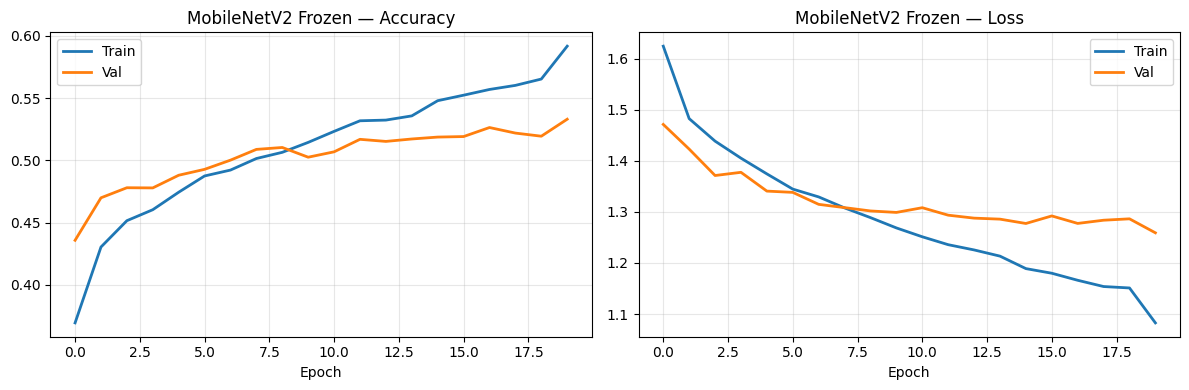

In [ ]:
# ── Train Model 2a: MobileNetV2 Frozen (feature extractor) ────────────────
print("=" * 60)
print("TRAINING MODEL 2a: MobileNetV2 Frozen Backbone")
print("=" * 60)

pretrained_frozen_model = build_pretrained_model(trainable=False)
history_frozen, time_frozen = compile_and_train(
    pretrained_frozen_model, train_ds_color, val_ds_color,
    epochs=20, lr=1e-3, model_name='mobilenet_frozen'
)
plot_history(history_frozen, 'MobileNetV2 Frozen')

TRAINING MODEL 2b: MobileNetV2 Fine-tuned
Epoch 1/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.3268 - loss: 1.7389
Epoch 1: val_accuracy improved from None to 0.44817, saving model to best_mobilenet_finetuned.keras

Epoch 1: finished saving model to best_mobilenet_finetuned.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 60s 92ms/step - accuracy: 0.3936 - loss: 1.5717 - val_accuracy: 0.4482 - val_loss: 1.4358 - learning_rate: 1.0000e-04
Epoch 2/20
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step - accuracy: 0.5137 - loss: 1.2886
Epoch 2: val_accuracy improved from 0.44817 to 0.50557, saving model to best_mobilenet_finetuned.keras

Epoch 2: finished saving model to best_mobilenet_finetuned.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 26s 58ms/step - accuracy: 0.5214 - loss: 1.2696 - val_accuracy: 0.5056 - val_loss: 1.2988 - learning_rate: 1.0000e-04
Epoch 3/20
448/449 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.5774 - loss: 1.1319
Epoch 3: val_accuracy improved from 0.50557 to 0.54374, saving model

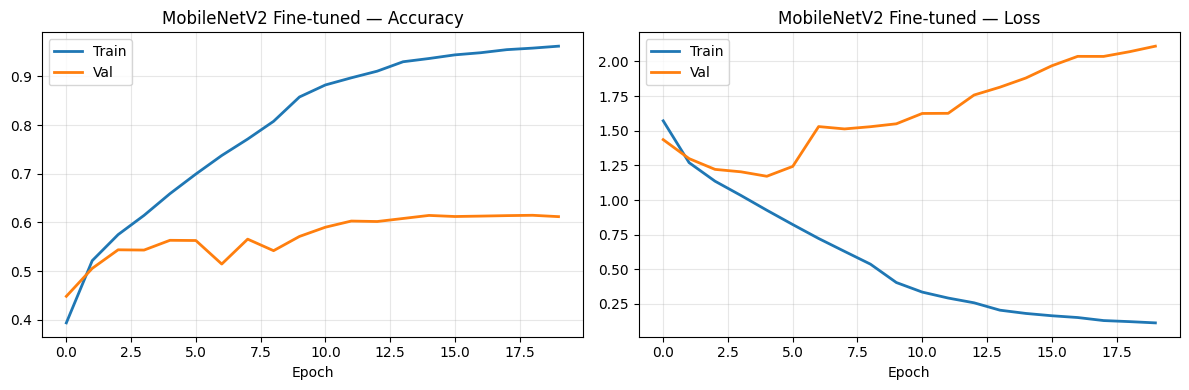

In [ ]:
# ── Train Model 2b: MobileNetV2 Fine-tuned (last 30 layers unfrozen) ──────
print("=" * 60)
print("TRAINING MODEL 2b: MobileNetV2 Fine-tuned")
print("=" * 60)

# Load the frozen model weights then unfreeze last 30 layers
finetuned_model = build_pretrained_model(trainable=True)
# Warm-start: copy weights from frozen head layers if sizes match
history_finetune, time_finetune = compile_and_train(
    finetuned_model, train_ds_color, val_ds_color,
    epochs=EPOCHS_FINETUNE, lr=1e-4,   # Lower LR for fine-tuning
    model_name='mobilenet_finetuned'
)
plot_history(history_finetune, 'MobileNetV2 Fine-tuned')

TRAINING MODEL 3: VGG-Style Double Conv Block
Epoch 1/50
449/449 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.2338 - loss: 1.8483
Epoch 1: val_accuracy improved from None to 0.24756, saving model to best_vgg_style.keras

Epoch 1: finished saving model to best_vgg_style.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 43s 70ms/step - accuracy: 0.2624 - loss: 1.7861 - val_accuracy: 0.2476 - val_loss: 2.0181 - learning_rate: 0.0010
Epoch 2/50
448/449 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step - accuracy: 0.3524 - loss: 1.6214
Epoch 2: val_accuracy improved from 0.24756 to 0.32460, saving model to best_vgg_style.keras

Epoch 2: finished saving model to best_vgg_style.keras
449/449 ━━━━━━━━━━━━━━━━━━━━ 23s 50ms/step - accuracy: 0.3764 - loss: 1.5661 - val_accuracy: 0.3246 - val_loss: 1.7374 - learning_rate: 0.0010
Epoch 3/50
448/449 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.4406 - loss: 1.4359
Epoch 3: val_accuracy improved from 0.32460 to 0.42366, saving model to best_vgg_style.keras

Epoch 3: finished 

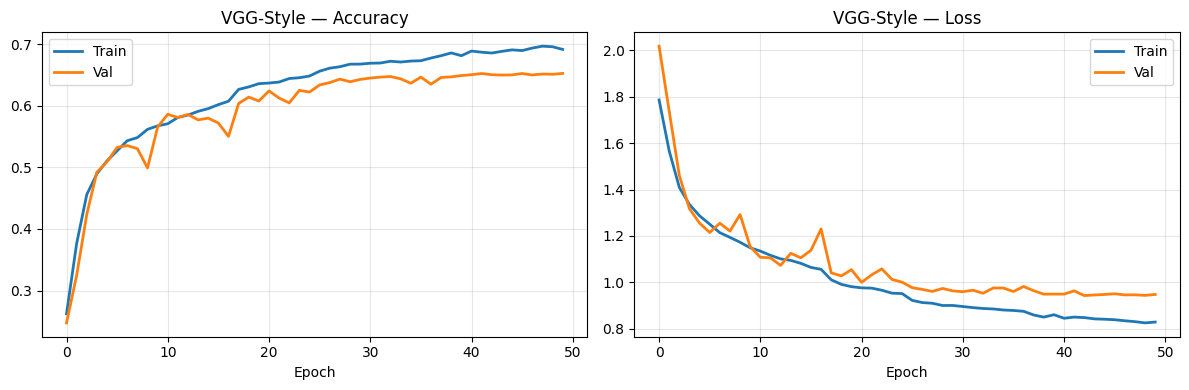

In [ ]:
print("=" * 60)
print("TRAINING MODEL 3: VGG-Style Double Conv Block")
print("=" * 60)

vgg_model = build_vgg_style_model()
history_vgg, time_vgg = compile_and_train(
    vgg_model, train_ds_gray, val_ds_gray,
    epochs=EPOCHS_SCRATCH, lr=1e-3, model_name='vgg_style'
)
plot_history(history_vgg, 'VGG-Style')

## Section 6.5 — Load Best Saved Models

In [ ]:
best_scratch = tf.keras.models.load_model('best_scratch_cnn.keras')
best_frozen = tf.keras.models.load_model('best_mobilenet_frozen.keras')
best_finetune = tf.keras.models.load_model('best_mobilenet_finetuned.keras')
best_vgg = tf.keras.models.load_model('best_vgg_style.keras')
print("All best models loaded.")

All best models loaded.



Model: CNN Scratch
              precision    recall  f1-score   support

       angry       0.61      0.62      0.62       958
     disgust       0.76      0.48      0.59       111
        fear       0.56      0.42      0.48      1024
       happy       0.86      0.87      0.86      1774
     neutral       0.59      0.68      0.63      1233
         sad       0.56      0.58      0.57      1247
    surprise       0.79      0.83      0.81       831

    accuracy                           0.68      7178
   macro avg       0.68      0.64      0.65      7178
weighted avg       0.68      0.68      0.67      7178



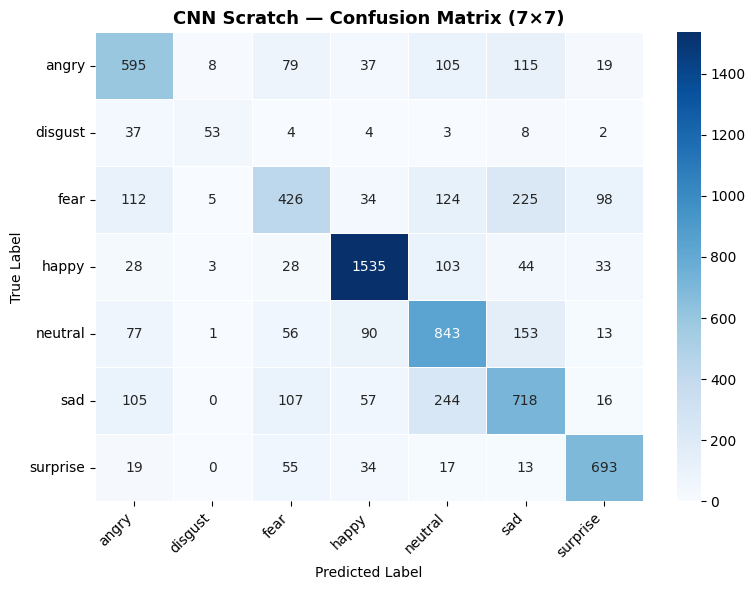


Model: MobileNet Frozen
              precision    recall  f1-score   support

       angry       0.40      0.47      0.43       958
     disgust       0.69      0.28      0.40       111
        fear       0.48      0.29      0.36      1024
       happy       0.66      0.74      0.70      1774
     neutral       0.48      0.51      0.50      1233
         sad       0.42      0.42      0.42      1247
    surprise       0.68      0.70      0.69       831

    accuracy                           0.53      7178
   macro avg       0.54      0.49      0.50      7178
weighted avg       0.53      0.53      0.53      7178



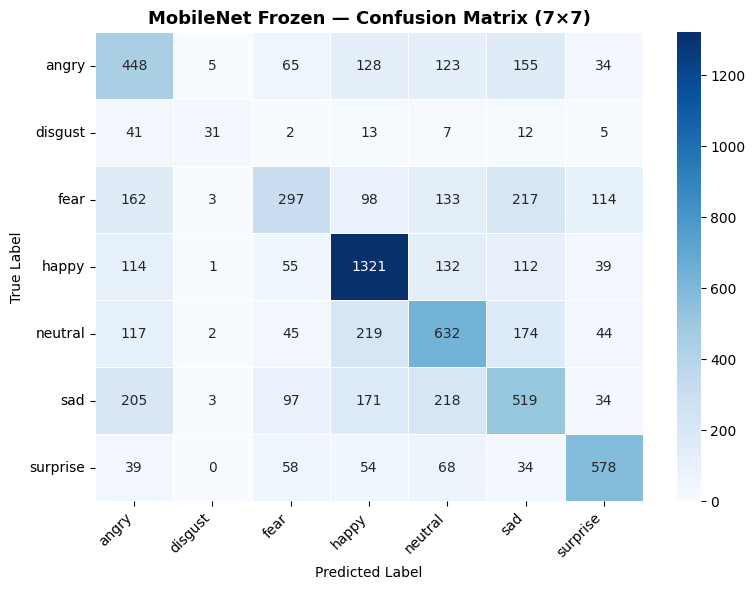


Model: MobileNet Finetune
              precision    recall  f1-score   support

       angry       0.54      0.53      0.53       958
     disgust       0.68      0.60      0.64       111
        fear       0.49      0.46      0.48      1024
       happy       0.76      0.83      0.79      1774
     neutral       0.56      0.53      0.54      1233
         sad       0.50      0.50      0.50      1247
    surprise       0.77      0.75      0.76       831

    accuracy                           0.61      7178
   macro avg       0.61      0.60      0.61      7178
weighted avg       0.61      0.61      0.61      7178



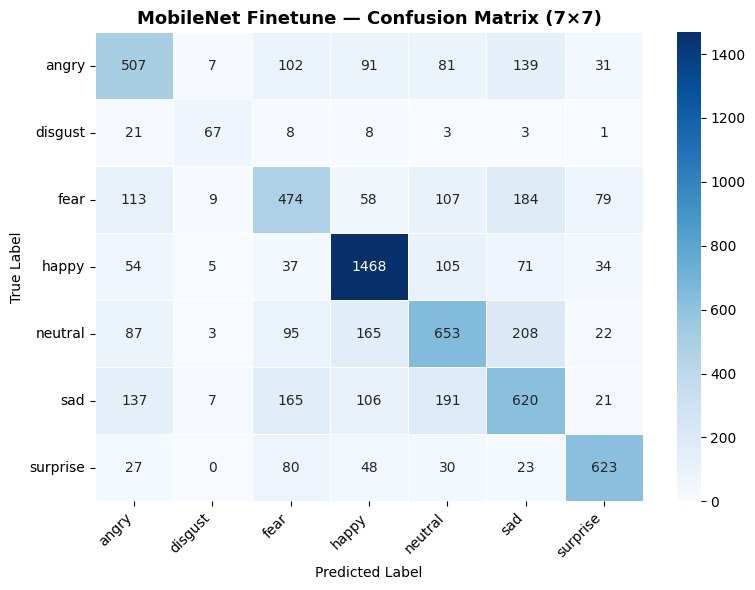


Model: VGG-Style
              precision    recall  f1-score   support

       angry       0.59      0.58      0.58       958
     disgust       0.58      0.35      0.44       111
        fear       0.53      0.32      0.40      1024
       happy       0.80      0.91      0.85      1774
     neutral       0.60      0.61      0.60      1233
         sad       0.51      0.60      0.55      1247
    surprise       0.78      0.78      0.78       831

    accuracy                           0.65      7178
   macro avg       0.63      0.59      0.60      7178
weighted avg       0.64      0.65      0.64      7178



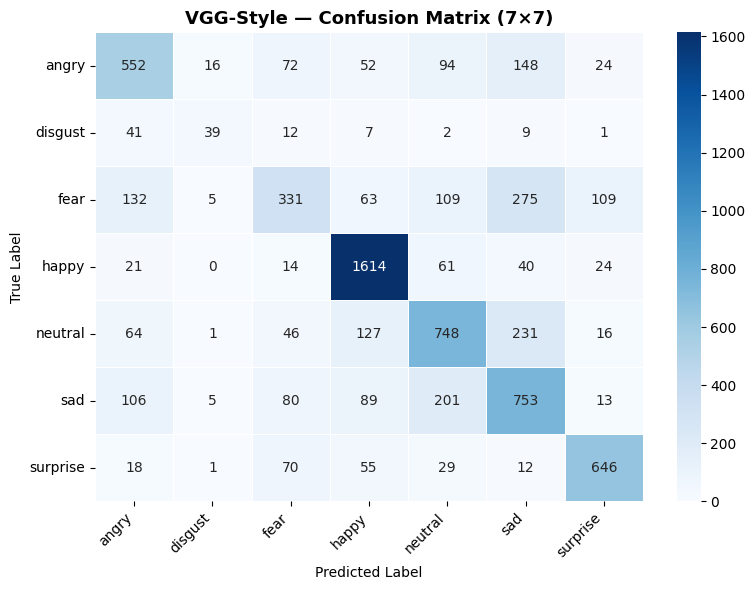

In [ ]:
def evaluate_model(model, val_ds, model_name):
    y_true, y_pred=[], []
    for batch_imgs, batch_labels in val_ds:
        preds = model.predict(batch_imgs, verbose=0)
        y_pred.extend(np.argmax(preds, axis=1))
        y_true.extend(np.argmax(batch_labels.numpy(), axis=1))

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    print(f"\n{'='*60}")
    print(f"Model: {model_name}")
    print('='*60)
    print(classification_report(y_true, y_pred, target_names=EMOTIONS))
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=EMOTIONS, yticklabels=EMOTIONS, linewidths=0.5)
    plt.title(f'{model_name} — Confusion Matrix (7×7)', fontsize=13, fontweight='bold')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.savefig(f'confusion_matrix_{model_name.lower().replace(" ","_")}.png',
                dpi=150, bbox_inches='tight')
    plt.show()
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    acc = np.mean(y_true == y_pred)
    return acc, macro_f1
results = {}
results['CNN Scratch'] = evaluate_model(best_scratch,val_ds_gray,  'CNN Scratch')
results['MobileNet Frozen'] = evaluate_model(best_frozen,val_ds_color, 'MobileNet Frozen')
results['MobileNet Finetune'] = evaluate_model(best_finetune, val_ds_color, 'MobileNet Finetune')
results['VGG-Style'] = evaluate_model(best_vgg,val_ds_gray,  'VGG-Style')

In [ ]:
param_counts = {
    'CNN Scratch': best_scratch.count_params(),
    'MobileNet Frozen': best_frozen.count_params(),
    'MobileNet Finetune': best_finetune.count_params(),
    'VGG-Style': best_vgg.count_params(),
}
train_times = {
    'CNN Scratch': time_scratch,
    'MobileNet Frozen': time_frozen,
    'MobileNet Finetune': time_finetune,
    'VGG-Style': time_vgg,
}
comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'Val Accuracy': [f'{v[0]*100:.2f}%' for v in results.values()],
    'Macro F1': [f'{v[1]:.4f}'      for v in results.values()],
    'Parameters': [f'{param_counts[k]:,}' for k in results],
    'Train Time(s)': [f'{train_times[k]:.0f}s' for k in results],
})
print("\n" + "="*70)
print(" MODEL COMPARISON TABLE")
print("="*70)
print(comparison_df.to_string(index=False))
best_model_name = max(results, key=lambda k: results[k][0])
print(f"\nBest model: {best_model_name} "
      f"(val accuracy = {results[best_model_name][0]*100:.2f}%)")


 MODEL COMPARISON TABLE
             Model Val Accuracy Macro F1 Parameters Train Time(s)
       CNN Scratch       67.75%   0.6507    323,047         1071s
  MobileNet Frozen       53.30%   0.4991  3,046,983          561s
MobileNet Finetune       61.47%   0.6058  3,046,983          548s
         VGG-Style       65.24%   0.6017    487,399         1079s

★  Best model: CNN Scratch (val accuracy = 67.75%)


In [ ]:
model_map = {
    'CNN Scratch': (best_scratch,'gray'),
    'MobileNet Frozen': (best_frozen,'color'),
    'MobileNet Finetune': (best_finetune,'color'),
    'VGG-Style': (best_vgg,'gray'),
}
DEPLOY_MODEL, DEPLOY_MODE = model_map[best_model_name]
DEPLOY_MODEL.save('emotion_model_deploy.h5')
print(f"Saved best model ({best_model_name}) → emotion_model_deploy.h5")
print(f"Input mode: {DEPLOY_MODE}")

Saved best model (CNN Scratch) → emotion_model_deploy.h5
Input mode: gray


In [ ]:
from google.colab import files
files.download("emotion_model_deploy.h5")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
model_map = {
    'CNN Scratch': (best_scratch,'gray'),
    'MobileNet Frozen': (best_frozen,'color'),
    'MobileNet Finetune': (best_finetune,'color'),
    'VGG-Style': (best_vgg,'gray'),
}
DEPLOY_MODEL, DEPLOY_MODE = model_map[best_model_name]
DEPLOY_MODEL.save('emotion_model_deploy.keras',include_optimizer=False)
print(f"Saved best model ({best_model_name}) → emotion_model_deploy.keras")
print(f"Input mode: {DEPLOY_MODE}")

Saved best model (CNN Scratch) → emotion_model_deploy.keras
Input mode: gray


In [ ]:
from google.colab import files
files.download("emotion_model_deploy.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import tensorflow as tf
model = tf.keras.models.load_model("/content/emotion_model_deploy.keras", compile=False)
model.save("fixed_model.keras")

In [ ]:
from google.colab import files
files.download("fixed_model.keras")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print("\n" + "="*65)
print(" LAB 14 — FINAL SUMMARY")
print("="*65)
print(f"Best Model       : {best_model_name}")
print(f"Val Accuracy     : {results[best_model_name][0]*100:.2f}%")
print(f"Macro F1-Score   : {results[best_model_name][1]:.4f}")
print(f"Parameters       : {param_counts[best_model_name]:,}")
print()



 LAB 14 — FINAL SUMMARY
Best Model       : CNN Scratch
Val Accuracy     : 67.75%
Macro F1-Score   : 0.6507
Parameters       : 323,047

Lab Concepts Integrated:
   1. Image preprocessing (grayscale, CLAHE, Gaussian blur, resize)
   2. OpenCV drawing (bounding boxes, text, confidence bars)
   3. Haar Cascade face detection
   4. CNN from scratch (3 conv blocks)
   5. Transfer learning: MobileNetV2 frozen backbone
   6. Fine-tuning: MobileNetV2 last 30 layers unfrozen
   7. VGG-style double conv block variant
   8. TF dataset pipeline with augmentation + prefetching
   9. deque(maxlen=20) stable emotion prediction
  10. VideoWriter annotated demo clip
